# **Class Programming Project: Reddit Sentiment Analysis**

Welcome to this mini-class programming project! In this project, you will explore and analyze Reddit data related to misogyny and offensive content. In the last few years, an astonishing raise in the amount of hate content aimed to women has been observed, especially embodied by the _Incel_ movement. Through, many Subreddits of the incel community have been banned (unfortunately still not stoping the growth of the movement because of plateform as Telegram or anonymous websites), a general misogyny can be observed in many women related forums. Here I propose to explore the content of one subreddit called 'TwoXChromosomes' through a simple sentiment analysis perspective. This idea here is to go through a simple pipeline from extracting the data to revealing communities which can be deepened for further analysis on your own.

This project will enhance your skills in the following areas:
- Data cleaning and preprocessing.
- Exploratory Data Analysis (EDA).
- Lexicon-based sentiment analysis using VADER.
- Text vectorization and feature extraction using embedding techniques such as Word2Vec.
- Implementation and evaluation of machine learning classifiers, including Random Forests.

## **Objectives**
1. Analyze the underlying structure of the dataset.
2. Conduct sentiment distribution analysis through data visualization.
3. Train and evaluate machine learning classifiers.
4. Benchmark model performance and critically evaluate the findings.
5. Investigate the propagation of sentiment across comments.


## **Libraires And Utilities**

In [1]:
# Pinning numpy strictly below 2.0 to guarantee gensim compatibility.
%pip install "numpy<2.0" praw gensim nltk transformers sentence-transformers matplotlib seaborn tqdm pandas scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import string
import praw
import praw
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from gensim.models import FastText
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import gensim.downloader as api
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
# Required initialization for VADER; fails silently if omitted until runtime
nltk.download('vader_lexicon', quiet=True)
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


In [3]:
# ================
# Load Data
# ================
df = pd.read_csv('/home/fabfab2001/Data_Mining/MiniProjet1/TwoXChromosomes_100_hot.csv')
df = df.dropna(subset=["body"])
df["clean_body"] = df["body"].astype(str)
texts = df["clean_body"].tolist()

print('--- First Five Texts of the Dataset ---\n')

for i, text in enumerate(texts[:5]):
    print(f"Comment {i+1}:")
    print(text)
    print("\n" + "="*50 + "\n") # Adds a visual jump/separator after each text

--- First Five Texts of the Dataset ---

Comment 1:
Your feelings and opinions are totally understandable to me. I do not have children and I am not religious. You should trust your instincts as a mother and care for your daughter the way that you want to. 

It’s strange to me that your husband cannot handle being alone for a few moments in church while you attend to the needs of his daughter, and seems to be so bothered by what others in the church think about your family unit.

Also I don’t think you should have to practice being away from her. Practice for what? Is he expecting you’ll be away from her for a while in the near future? 

You are entirely reasonable for not trusting strangers with your child. Just because they are members of a church does not mean they are automatically trustworthy or even deserving of your complete and total trust.


Comment 2:
This is a two-yeses-or-it’s-no situation. There’s no reason that she needs to be in the nursery at any age.


Comment 3:
Frank

# **Text Preprocessing**


1. After executing the initial preprocessing cell, compute the 10 most frequent words across the dataset to verify the effectiveness of your cleaning pipeline.

**Note on Data Structure:** Keep in mind the shape of your data. The `texts` variable (and the `df["clean_body"]` column) is a sequence containing multiple, independent strings, one for each Reddit post or comment. Your `clean_text` function must be applied to each document individually (e.g., using the `.apply()` method on the Pandas Series) *before* you join them together to compute the global word frequencies.

*Hint: You are encouraged to use `stopwords.words("english")` from the `nltk.corpus` module and the `Counter` class from the `collections` library to complete this task as the method `.split()` on your input text string! *

In [4]:

# Make sure stopwords are downloaded and set up
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Cleans a single text string (representing one individual Reddit post or comment).

    WARNING: This function expects a single string as input (e.g., "This is a comment").
    Do not pass an entire list or a Pandas Series directly into this function.
    Use the .apply() method to run this function row-by-row on your dataframe.

    Args:
        text (str): The raw text of a single Reddit comment.

    Returns:
        str: The fully cleaned and preprocessed text.
    """
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # Remove Reddit mentions (r/subreddit, u/user)
    text = re.sub(r'(r/|u/)[A-Za-z0-9_]+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # ADD STOPWORDS CLEANING
    ### COMPLETE HERE ###

    text = " ".join([word for word in text.split() if word not in stop_words])

    return text


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/fabfab2001/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
#1. Apply your cleaning function to the df["clean_body"] and check the 10 most frequent words in the tweets and interpret your result.

# prend ligne par ligne
df["clean_body"] = df["body"].apply(clean_text)

# fusionne toutes les lignes et compte les mots
toutMots = " ".join(df["clean_body"]).split()
frequenceMots = Counter(toutMots)

print("Top 10 des mots les plus frequents \n")
for word, count in frequenceMots.most_common(10):
    print(f"{word}: {count}")

Top 10 des mots les plus frequents 

like: 2148
women: 1931
people: 1687
men: 1649
would: 1393
get: 1392
dont: 1306
one: 1207
want: 1173
think: 1119


## **COMMENTS:**

> Ca semble fonctionner et le top 10 des mots semble etre les mots attendu. Des déterminants, mots de liaisons, verbe etre "is".  
> Ce qui est logique car on utilise les stopwords.

-----------------------------------------------------------------------------
# **TASK II.1. Lexicon-Based Sentiment Analysis**

## **Objective**
Investigate the sentiment profile of the subreddit using VADER (Valence Aware Dictionary and sEntiment Reasoner). You are expected to design processing pipeline to extract multiple dimensions of sentiment from your cleaned text and visually analyze the resulting distributions.


Consult the [VADER Documentation](https://vadersentiment.readthedocs.io/en/latest/pages/introduction.html) to understand the `SentimentIntensityAnalyzer` class. Implement a solution that yields the following deliverables:

1. **The Updated DataFrame:** Your primary dataframe must be updated to include four entirely new, distinct numeric columns representing the VADER outputs for each Reddit comment:
   * `Negative_Score`
   * `Neutral_Score`
   * `Positive_Score`
   * `Compound_Score`

2. **Visual Exploration:** Produce clear, academically appropriate visualizations (e.g., histograms, kernel density estimates, or boxplots) that accurately capture the distribution of these sentiment metrics across the entire dataset.



In [6]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/fabfab2001/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
#1. Compute and store the `polarity scores` for each tweet

# Initialisation
sia = SentimentIntensityAnalyzer()

# J aplique VADER aux commentaires sans les stopwords
sentiment_scores = df["clean_body"].apply(lambda text: sia.polarity_scores(text))

df["Negative_Score"] = sentiment_scores.apply(lambda x: x["neg"])
df["Neutral_Score"]  = sentiment_scores.apply(lambda x: x["neu"])
df["Positive_Score"] = sentiment_scores.apply(lambda x: x["pos"])
df["Compound_Score"] = sentiment_scores.apply(lambda x: x["compound"])

print(df[[
    "clean_body",
    "Negative_Score",
    "Neutral_Score",
    "Positive_Score",
    "Compound_Score"
]].head())

                                          clean_body  Negative_Score  \
0  feelings opinions totally understandable child...           0.057   
1  twoyesesorit’sno situation there’s reason need...           0.000   
2  frankly church isnt delighted children church ...           0.127   
3  “i’m i’ll sit back get cries” don’t know she’s...           0.221   
4  dont church let 12 13 year olds watch babies o...           0.130   

   Neutral_Score  Positive_Score  Compound_Score  
0          0.671           0.272          0.9362  
1          1.000           0.000          0.0000  
2          0.777           0.096         -0.7234  
3          0.576           0.203         -0.2484  
4          0.779           0.091         -0.2263  


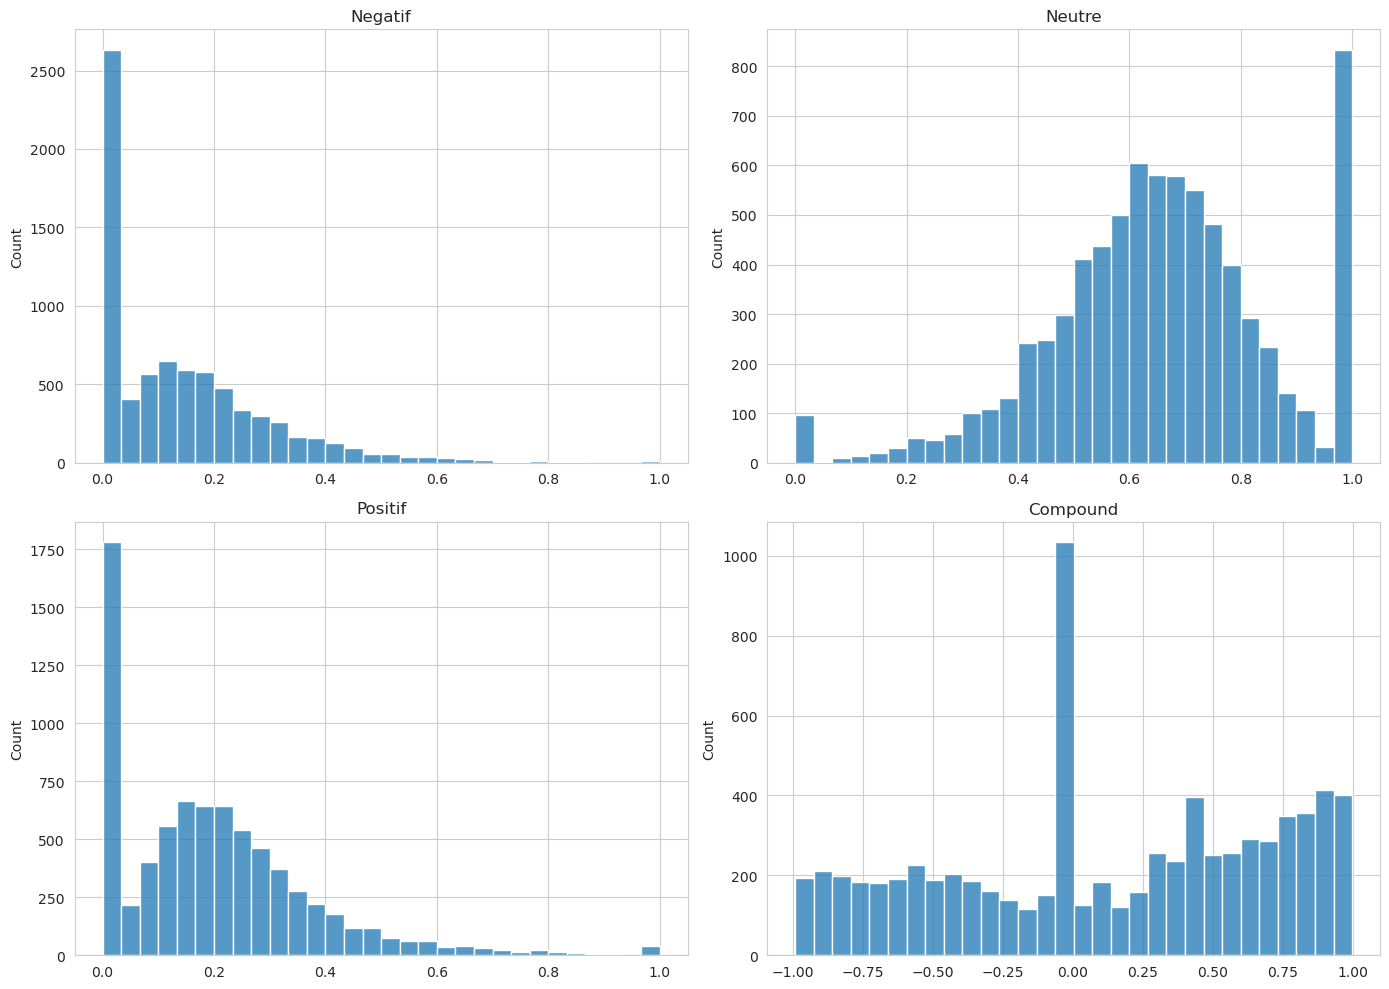

In [8]:
#2.  Plot the distribution and cumulative distribution of the sentiments

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df["Negative_Score"].to_numpy(),       #  Négatif
             bins=30,
             ax=axes[0,0])

axes[0,0].set_title("Negatif")

sns.histplot(df["Neutral_Score"].to_numpy(),        # Neutre
             bins=30,
             ax=axes[0,1])

axes[0,1].set_title("Neutre")

sns.histplot(df["Positive_Score"].to_numpy(),       # Positif
             bins=30,
             ax=axes[1,0])

axes[1,0].set_title("Positif")

sns.histplot(df["Compound_Score"].to_numpy(),       # Compound
             bins=30,
             ax=axes[1,1])

axes[1,1].set_title("Compound")

plt.tight_layout()
plt.show()

> Le subreddit semble pencher un peu vers le positif. Donc les discussions sont plutot empathique, sans haine, supporte la communauté, etc. Le grand pic dans la distribution à 0.0, c'est pas parceque les discussions sont dénudé sentiments. Mais plutot les limites du lexicon VADER qui n'arrive pas a identifier toutes les intentions des commentaire. Quand VADER ne détecte pas de bias positif ou négatif c'est classé comme neutre. Donc plus il manque les  indices, plus de discussions sont classé comme neutre 0.0  
  
> Les rule-based sont prédéterminé. La pérformance de l'outil, dépend complétement sur les compétences du créateur du lexicon et ne s'adapte pas au text analysé.  
Alors qu'un ML classifier va pouvoir s'adapter a chaque text analyser et peut déduire le sens selon le context. Il pourra mieux détecter le sarcasme, humour, du jargon. Et pour des discussions tiré d'internet en particulier il est mieux adapter aux memes, acronymes et références de pop-culture.  

> La distribution de neutre est expliqué par "neu=1−(pos+neg)" donc si une phrase a contient des mots positif et négatif ils s'annulent et sont classé comme neutre. Ce qui a tendance a avoir une espérence proche de 0.5.  
Les distributions de positif et nagatif sont concentré vers 0 car ceci dépend des coeff attribué par par le lexicon de VADER.


--------------------------------------------------------------
# **TASK II.2. Lexicon-Based Sentiment Analysis**

## **Objective**
Now that you have quantified the overall sentiment of the dataset, your next objective is to identify *what* is driving that sentiment. You will isolate the most extreme positive and negative comments and analyze their underlying vocabulary.


1. **Isolate Extreme Subsets:** * Sort your dataframe based on the `Compound_Score` you calculated in Task II.
   * Extract two new, separate dataframes: one containing the top 50 most **positive** comments and another containing the top 50 most **negative** comments.

2. **Compute Word Frequencies:**
   * Reusing the logic and tools from Task I (e.g., `Counter`), calculate the 15 most frequent words within the *positive* dataframe, and the 15 most frequent words within the *negative* dataframe.
   * *Crucial Note:* Ensure you are running this frequency analysis on your `clean_body` column to avoid counting stopwords and punctuation.


In [9]:
## 1. Isolate Extreme Subsets

df_sorted = df.sort_values(by="Compound_Score")

# top 50 commentaire negatifs
df_negatif_extreme = df_sorted.head(50)

# top 50 commentaires positifs
df_positif_extreme = df_sorted.tail(50)

motsPositfs = " ".join(df_positif_extreme["clean_body"]).split()
nbr_parution_positifs = Counter(motsPositfs)
print("--- Top 15 Words in Positive Comments ---\n")
for word, count in nbr_parution_positifs.most_common(15):
    print(f"{word}: {count}")

--- Top 15 Words in Positive Comments ---

like: 75
time: 64
kids: 60
get: 55
life: 52
also: 48
things: 46
love: 46
people: 43
would: 42
feel: 41
child: 40
work: 39
even: 39
make: 38


In [10]:
## 2. Compute Word Frequencies

motsNegatifs = " ".join(df_negatif_extreme["clean_body"]).split()

parution_negatifs = Counter(motsNegatifs)

print("--- Top 15 Words in Negative Comments ---\n")
for word, count in parution_negatifs.most_common(15):
    print(f"{word}: {count}")

--- Top 15 Words in Negative Comments ---

people: 44
women: 43
get: 38
dont: 37
men: 36
even: 33
like: 31
sex: 26
time: 25
think: 24
also: 23
one: 23
abuse: 22
didnt: 22
way: 21


> Dans la liste du top 15 mots positifs parmis le top 50 des commentaires positifs on retrouve "time", "kids", "life, "love", etc qui sont dans le theme de la vie, de la famille et de la joie.  
> Alors que dans la liste du top 15 mots négatifs parmis le top 50 des commentaires négatifs on retourve "women", "men", "dont", "abuse", "didnt" etc donc des themes comme l'abus, homme femme, et des formes de négation.  
> Les résultats font relativement sens quand on sait que le sub-reddit vise les hommes et qu'il est connu pour de la misoginie et de l'incel.  
> Le fait que le mot "women" se retourve parmis les mots négatifs appuie cette idée.  
  
> Les mots comme "like", "time", "people", n'ont pas de conotation intraseque, elle dépend du context et de la manière qu'ils sont utilisé.  
> Ca montre que la methode du rule-based est mauvais lorsqu'il s'agit de contextualiser le sens des mots ambigus. C'est pas parce que le mots est souvent utilisé que ca signifie qu'il a beacoup d'importance.  
  
> La présence de mots dans la liste négative n'implique pas directement de mauvaise intentions. Le mot "abuse" a probablement une conotation très négative dans le lexicon mais le mot "sex" pas focément. Mais si dans une phrase du type; "This law applies to victims of sex abuse.", l'intention est bonne mais VADER lui donnerait une mauvaise connotation simplement car des mots comme "abuse" mal connoté se trouve dedans. Puis si "sex" se retrouve souvent avec "abuse" il tombra dans la liste négative.

--------------------------------------------------------------------------------
# **TASK III. Word Embeddings & Semantic Clustering**

## **Objective**
Transition from rule-based sentiment to **Machine Learning**. You will transform text into dense numerical vectors (Word Embeddings) that capture semantic meaning. You will then determine if these mathematical representations naturally "cluster" into the sentiment categories defined by VADER.

### **1. Assign Ground Truth Labels**
Using the `Compound_Score` calculated in Task II, create a new column `Sentiment_Label`. Follow the official VADER thresholds:
* **POS (0)**: `Compound_Score >= 0.05`
* **NEU (1)**: `-0.05 < Compound_Score < 0.05`
* **NEG (2)**: `Compound_Score <= -0.05`

### **2. Tokenization & Embedding Generation**
Transform the `clean_body` into numerical features:
1.  **Tokenize**: Use `nltk.word_tokenize` to turn each comment into a list of strings (note: convert each comment in `str` and in small letters using `.lower()` before applying `nltk.word_tokenize`)
2.  **Initialize & Train FastText**: Instead of doing this in one line, explicitly perform the three steps of model training to understand how the architecture works:
    * **Step A (Initialization)**: Create an empty `FastText` model. *Hint: Consider parameters like `vector_size` (try 64 or 100), `window` size, and `min_count`. Use the Skip-gram architecture (`sg=1`). FastText is superior to Word2Vec here because it uses **sub-word information**, allowing it to handle typos, slang, and "internet-speak".*
    * **Step B (Build Vocabulary)**: Use the `.build_vocab()` method to scan your tokens and learn what words exist in your dataset.
    * **Step C (Train)**: Use the `.train()` method to actually calculate the vectors. *Hint: You will need to pass your tokens, the total number of examples (`model.corpus_count`), and the number of epochs (`model.epochs`).*
3.  **Vector Extraction**: For each comment, retrieve the vectors for all its words**.
    * **Warning**: While FastText can generate vectors for unknown words, you must still handle "Empty Vectors." If a comment has zero tokens (e.g., if it only contained punctuation or symbols that were cleaned), how will you represent it? (e.g., a vector of zeros).

### **3. Dimensionality Reduction & Visualization**
You cannot visualize a high-dimensional vector directly.
1.  Apply a dimensionality reduction technique (e.g., **PCA**, **t-SNE**, or **UMAP**) to project your comment vectors into **2D space**.
2.  Create a scatter plot where each point is a comment, colored by its `Sentiment_Label`. Use a logical color palette (e.g., Green for POS, Blue for NEU, Red for NEG).



--------------------------------------------------------------------------------

### **NOTE: What is FastText?**
**FastText** is an evolution of the traditional embedding Word2Vec model. While standard models treat each word as an indivisible unit, FastText looks *inside* the word to understand its structure.

#### **The Mechanism: Sub-word Information**
FastText breaks words down into smaller chunks called **character n-grams**. For example, if we represent the word `<apple>` with $n=3$, the model sees:
* `<ap`, `app`, `ppl`, `ple`, `le>`

The final vector representation for a word is the **sum** of the vectors of its $n$-grams. Formally, for a word $w$ and its set of n-grams $\mathcal{G}_w$:

$$v(w) = \sum_{g \in \mathcal{G}_w} \mathbf{z}_g$$

#### **Why use FastText for Reddit Data?**
Traditional models like Word2Vec often fail on social media data because they cannot handle **Out-of-Vocabulary (OOV)** words. If a model hasn't seen a specific word during training, it doesn't know what to do with it.

**FastText solves this in three ways:**
1.  **Robustness to Typos:** If the model knows "disaster," it can still understand "disaaaaaster" because they share most of the same character n-grams.
2.  **Slang & Morphology:** It recognizes that "eating," "eats," and "eaten" are related because of their shared root n-grams.
3.  **Contextual Intelligence:** By looking at sub-words, it captures semantic nuances in "internet-speak" that whole-word models completely miss.
--------------------------------------------------------------------------------



In [ ]:
# ---------------------------------------------------------
# 1. Setup & Resource Download
# ---------------------------------------------------------
# Ensure all NLTK components are present
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True) # Required for modern NLTK tokenizers

# ---------------------------------------------------------
# 1. Define Sentiment Labels
# ---------------------------------------------------------
# We use the standard academic thresholds (+0.05 and -0.05)
vader = SentimentIntensityAnalyzer()

def get_vader_label(text):
    """
    Return the assigned label (either "POSITIVE", "NEGATIVE" or "NEUTRAL")
    based on VADER scoring
    """
    score = vader.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "POSITIVE"
    elif score <= -0.05:
        return "NEGATIVE"
    else:
        return "NEUTRAL"
    


print("Applying VADER labels to dataset...")
df["sentiment_vader"] = df["clean_body"].apply(get_vader_label)

# ---------------------------------------------------------
# 2.1 Tokenization
# ---------------------------------------------------------
print(" Tokenizing text for embedding...")


df["tokens"] = df["clean_body"].apply(
    lambda x: nltk.word_tokenize(str(x).lower())
)


# ---------------------------------------------------------
# 2.2 Train the Embedding Model
# ---------------------------------------------------------

# Initialize Model parameters
sentences = df["tokens"].dropna().tolist()
sentences = [list(map(str, s)) for s in sentences]
ft_model = FastText(
    vector_size=100,
    window=5,
    min_count=2,
    sg=1
)

print("Building the vocabulary dictionary...")
# Step 1: The model must learn what words exist in the dataset

ft_model.build_vocab(corpus_iterable=sentences)

print("Training the model (learning the vectors)...")
# Step 2: Actually train the network
ft_model.train(
    corpus_iterable=sentences,
    total_examples=len(sentences),
    epochs=ft_model.epochs
)

# ---------------------------------------------------------
# 2.3 Comment Vectorization
# ---------------------------------------------------------
def get_comment_vector(tokens, model):
    """
    Computes the extractor final embedding vector for a list of tokens.
    If no words are recognized, returns a vector of zeros.
    """
    if len(tokens) == 0:
        return np.zeros(model.vector_size)

    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)



print("Generating numerical embeddings for all comments...")
# We use a list comprehension for efficiency
embeddings = [get_comment_vector(t, ft_model) for t in tqdm(df["tokens"])]

# Store the resulting vectors in the DataFrame
df["embedding"] = embeddings

Applying VADER labels to dataset...
 Tokenizing text for embedding...
Building the vocabulary dictionary...
Training the model (learning the vectors)...
Generating numerical embeddings for all comments...


100%|██████████| 7632/7632 [00:01<00:00, 7034.11it/s]


/home/fabfab2001/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/fabfab2001/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


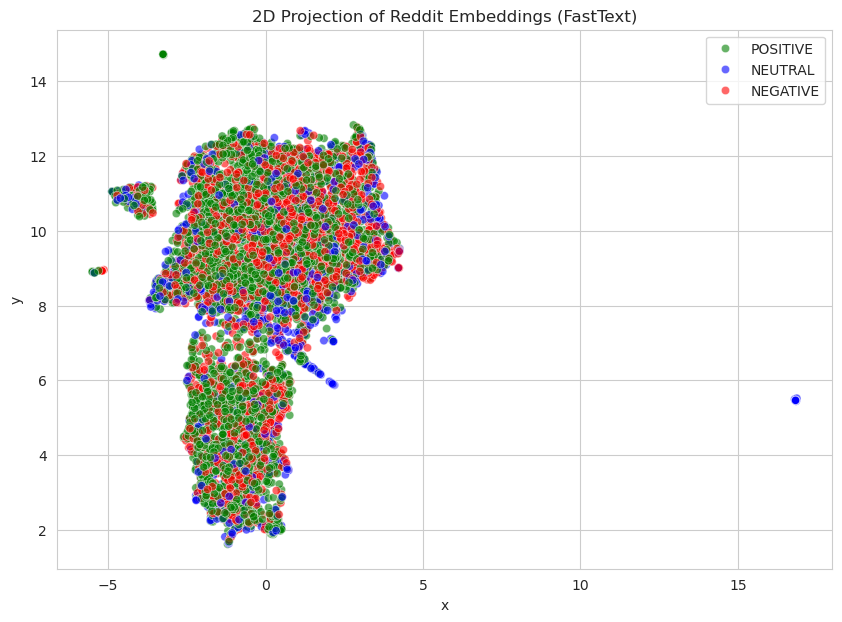

In [12]:
#3.
# ========================
# Prepare Embeddings from DataFrame Columns
# ========================

X = np.vstack(df["embedding"].values)

# ========================
# Dimensionality Reduction and 2D Projection
# ========================

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

X_2d = reducer.fit_transform(X)
df["x"] = X_2d[:, 0]
df["y"] = X_2d[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="sentiment_vader",
    palette={"POSITIVE": "green", "NEUTRAL": "blue", "NEGATIVE": "red"},
    alpha=0.6
)

plt.title("2D Projection of Reddit Embeddings (FastText)")
plt.legend()
plt.show()

> Les commentaires négatifs, neutres et positifs ne forment pas de clusters, ils se mélangent/superposent partout.  
  
> FastText ne capture pas de "sentiment" correctement car on voit que les commentaire ne créent pas de cluster selon leur "émotions", tout est mélangé.  
> Je crois plutot que les 2 clusters qui apparaisent capture plutot la sémantique et des sujets.  
  
> Le probleme principal de cette méthode est qu'on perde la notion d'ordre de partution des mots. Ce qui est très important. Par exemple pour les négations si on a "not good" il est facile de comprendre que la sentiment de "good" ici est négatif. Si on traite tout les mots individuellement, "good" va biaiser le sens de la phrase positiivement. Donc tout transformer en un seul vecteur nous fausse grandement les résultats car l'ordre des mots leur donne un sens.

--------------------------------------------------------------------------------
# **TASK IV. Classification Sentiment Analysis**

## **Classification and Benchmarking**

Now that you have generated embeddings for the comments, the next step is to build and evaluate a **classification pipeline**. The goal of this task is to **classify tweets by sentiment** using the embeddings you created and to **benchmark a machine learning model**.

Benchmarking in this context means testing multiple model' parameters sets, comparing their performance (e.g., accuracy, F1-score, differnce between train and test score), and analyzing which one is most suitable for the sentiment classification problem based on your data and feature representation.

---


### **1. Prepare the Data & Balance Classes**

Before training a machine learning classifier, you must prepare your feature matrix and ensure your data allows the model to learn fairly.

* **Extract Features & Labels:** Use the comment embeddings generated in the previous task as your feature vectors ($X$). Then, convert your categorical sentiment labels (POSITIVE, NEGATIVE, NEUTRAL) into numerical target values ($y$) using `LabelEncoder` from `sklearn.preprocessing` (as seen in Session #4).

* **Check and Fix Class Imbalance (Mandatory):** Check the distribution of your sentiment labels (e.g., using `pd.Series(y).value_counts()`). Real-world social media data is rarely perfectly balanced. If one sentiment heavily outweighs the others, your model will become biased toward predicting that majority class. You must balance your dataset by **oversampling** the minority classes to match the majority class size. *(Hint: use the `resample` function from `sklearn.utils`)*.

* **Train-Test Split:** Once your data is perfectly balanced, split it into a **training set** and a **test set** (e.g., an 80/20 split using `train_test_split` from `sklearn.model_selection`). This step is absolutely essential to evaluate how well your model will generalize to entirely unseen data.

### 2. **Train and Evaluate Your Model**

Now that your data is balanced and split, it is time to teach the machine to recognize sentiment patterns in the 64-dimensional FastText vectors.

1. **Define Classification Models**  
   Create and initialise classification model, here `RandomForestClassifier` function from `sklearn.ensemble module` [doc](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). (Feel free to try an additional model if you want)
   - **Random Forest**




* **Model Selection & Training:** Instantiate a classifier of your choice (e.g., `RandomForestClassifier` or `LogisticRegression`). Train (`.fit()`) your model using strictly the **training set** ($X\_train$, $y\_train$).
* **Prediction:** Use your trained model to predict (`.predict()`) the labels for your **test set** ($X\_test$).
* **Evaluation Metrics:** Do not rely on Accuracy alone! Use `classification_report` from `sklearn.metrics` to calculate the **Precision**, **Recall**, and **F1-score** for each individual class.
* **Visualizing Errors:** Generate and plot a **Confusion Matrix** (`confusion_matrix` from `sklearn.metrics` mapped with `seaborn.heatmap`). This will visually reveal which specific sentiments your model is confusing (e.g., is it misclassifying Negative comments as Neutral?).

---

### **3. Benchmark & Diagnostics (The Learning Curve)**


* **Plot the Learning Curve:** Use the `learning_curve` function from `sklearn.model_selection`. This function trains the model on increasing subsets of the training data and calculates scores for both the training set and a cross-validation set.
* **Visualize:** Plot the "Training Score" and "Cross-Validation Score" on the y-axis against the "Training Set Size" on the x-axis using `matplotlib`.



In [ ]:
#1.

# ==========================================
# Step 1: Encode the sentiment labels & Extract Features (X) and Target (y)
# ==========================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["sentiment_vader"])    

# Print Mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


#'embedding' column from DataFrame into a numpy array for X.
X = np.vstack(df["embedding"].values)   
y = y_encoded

# Combine X and y into a temporary DataFrame for easier resampling
data = pd.DataFrame({'embedding': list(X), 'label': y})

# Separate the dataset into majority and minority classes
majority_label = data['label'].value_counts().idxmax()
data_majority = data[data['label'] == majority_label]
data_minority_list = [data[data['label'] == label] for label in data['label'].unique() if label != majority_label]

# ==========================================
# Step 3: Oversample the minority classes
# ==========================================
resampled_minority_list = []

for minority in data_minority_list:

    resampled_minority = resample(
        minority,
        replace=True,
        n_samples=len(data_majority),
        random_state=42
    )

    resampled_minority_list.append(resampled_minority)

# Combine majority class with the newly oversampled minority classes
data_balanced = pd.concat([data_majority] + resampled_minority_list)

# Shuffle the dataset to prevent ordered blocks of identical labels
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Extract the balanced X and y back into clean numpy arrays
X_balanced = np.stack(data_balanced['embedding'])
y_balanced = data_balanced['label'].values

print("New class balance after resampling:\n", pd.Series(y_balanced).value_counts())

# ==========================================
# Step 3: Train-Test Split
# ==========================================

resampled_minority_list = []

for minority in data_minority_list:

    resampled_minority = resample(
        minority,
        replace=True,
        n_samples=len(data_majority),
        random_state=42
    )

    resampled_minority_list.append(resampled_minority)

# fusionne la majorité + oversampled minorité
data_balanced = pd.concat([data_majority] + resampled_minority_list)

# mélange
data_balanced = data_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_balanced = np.stack(data_balanced['embedding'])
y_balanced = data_balanced['label'].values

print("Nouvelle classe équilibrée après resampling : \n",
      pd.Series(y_balanced).value_counts())


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)


print(f"Taille du set d'entrainement: {len(X_train)}")
print(f"Taille du set de testing: {len(X_test)}")

Label Mapping: {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
New class balance after resampling:
 2    4000
1    4000
0    4000
Name: count, dtype: int64
Nouvelle classe équilibrée après resampling : 
 2    4000
1    4000
0    4000
Name: count, dtype: int64
Taille du set d'entrainement: 9600
Taille du set de testing: 2400


Random Forest Accuracy: 0.8525

Classification Report:

              precision    recall  f1-score   support

    NEGATIVE       0.80      0.81      0.81       800
     NEUTRAL       0.94      0.98      0.96       800
    POSITIVE       0.81      0.77      0.79       800

    accuracy                           0.85      2400
   macro avg       0.85      0.85      0.85      2400
weighted avg       0.85      0.85      0.85      2400



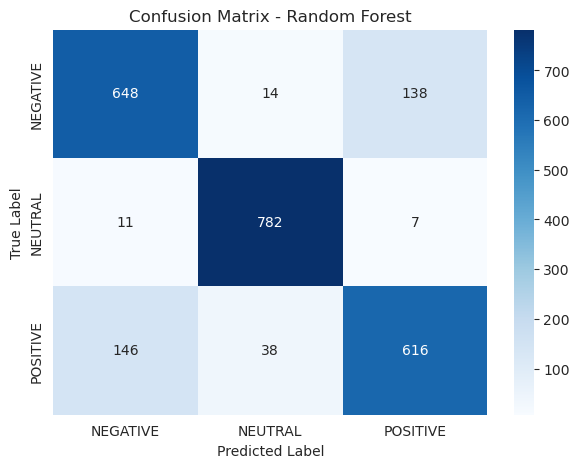

In [ ]:
#2. Train and Evaluate The Choosen Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrainement
rf_model.fit(X_train, y_train)

# Prédiction
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")


print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

/home/fabfab2001/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Accuracy: 0.6879

Classification Report:

              precision    recall  f1-score   support

    NEGATIVE       0.65      0.53      0.59       800
     NEUTRAL       0.85      0.85      0.85       800
    POSITIVE       0.57      0.68      0.62       800

    accuracy                           0.69      2400
   macro avg       0.69      0.69      0.69      2400
weighted avg       0.69      0.69      0.69      2400



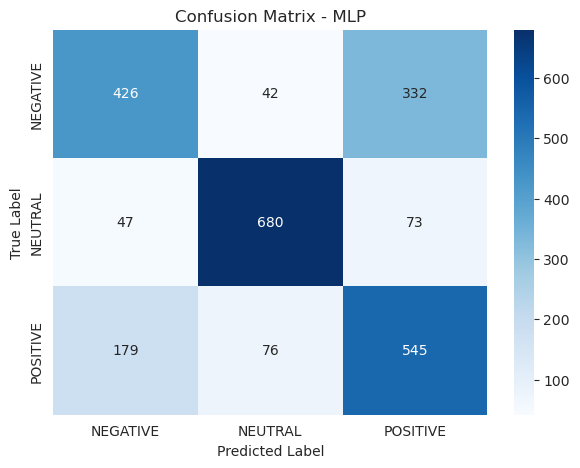

In [ ]:
## Multi-Layer Perceptron Classifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    random_state=42
)

# Entrainement
mlp_model.fit(X_train, y_train)

# Prédiction
y_pred_mlp = mlp_model.predict(X_test)

# Accuracy
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Accuracy: {mlp_accuracy:.4f}")

# Classification Report
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_mlp,
    target_names=label_encoder.classes_
))

# Confusion Matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

Training and Evaluating Random Forest ---

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

    NEGATIVE       0.80      0.81      0.81       800
     NEUTRAL       0.94      0.98      0.96       800
    POSITIVE       0.81      0.77      0.79       800

    accuracy                           0.85      2400
   macro avg       0.85      0.85      0.85      2400
weighted avg       0.85      0.85      0.85      2400



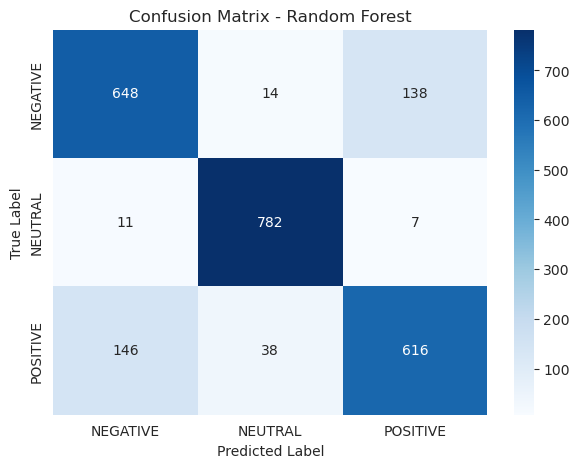

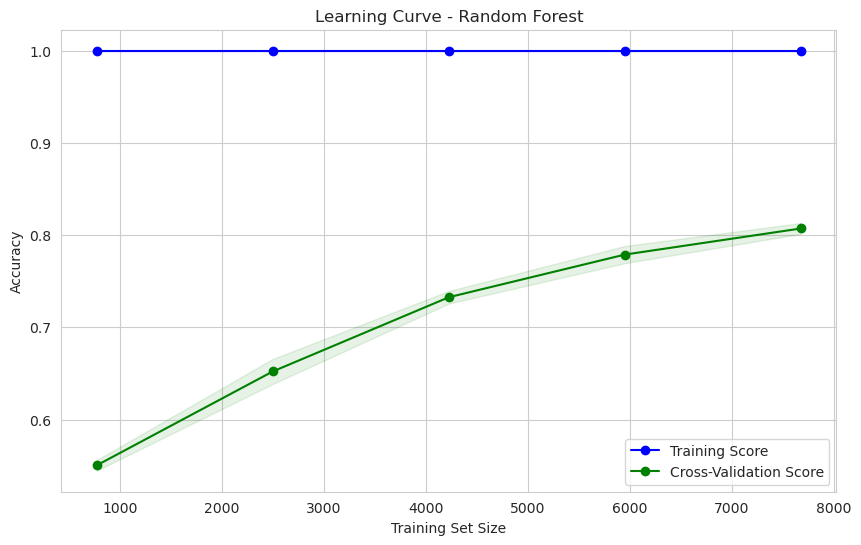

Training and Evaluating MLP Classifier ---


/home/fabfab2001/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



=== MLP Classifier Classification Report ===
              precision    recall  f1-score   support

    NEGATIVE       0.65      0.53      0.59       800
     NEUTRAL       0.85      0.85      0.85       800
    POSITIVE       0.57      0.68      0.62       800

    accuracy                           0.69      2400
   macro avg       0.69      0.69      0.69      2400
weighted avg       0.69      0.69      0.69      2400



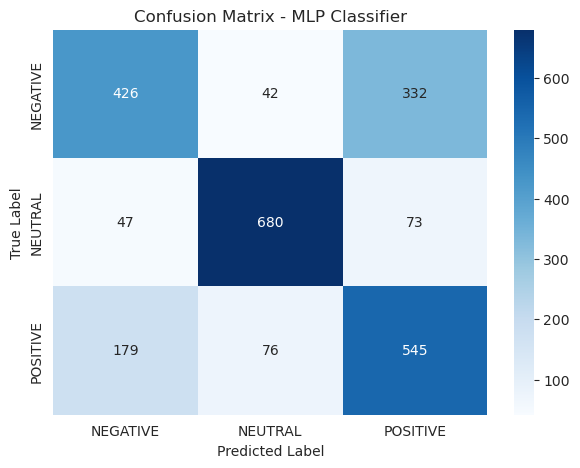

/home/fabfab2001/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/fabfab2001/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/fabfab2001/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/fabfab2001/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/fabfab2001/.local/lib/pyth

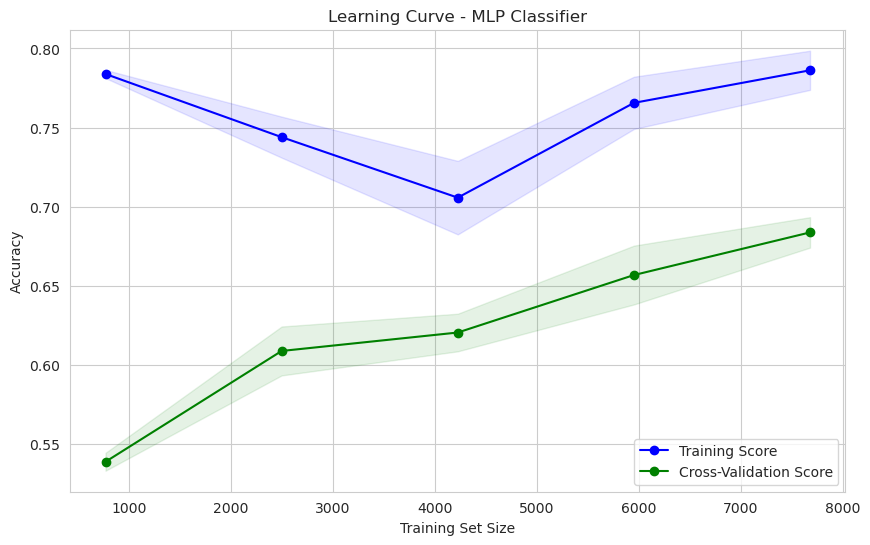

" ATTENTION sur mon ordi ca a pris 5m 46s a s'executer ! "

In [ ]:

def evaluate_and_plot_learning_curve(model, X_train, y_train, X_test, y_test, model_name):
    print(f"Training and Evaluating {model_name} ---")

    # ==========================================
    # Step 1: Train and Predict
    # ==========================================
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    # ==========================================
    # Step 2: Evaluation Metrics
    # ==========================================
    print(f"\n=== {model_name} Classification Report ===")


    ### COMPLETE HERE ###
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))



    # TODO: Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)  ### COMPLETE HERE ###

    # Plot confusion matrix
    plt.figure(figsize=(7,5))

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

    # ==========================================
    # Step 3: Learning Curve (Advanced Diagnostic)
    # ==========================================
    from sklearn.model_selection import learning_curve
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )



    ## AGGREGATE RESULTS OVER THE FOLDS
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)

    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)


    # Plotting the Learning Curve
    plt.figure(figsize=(10,6))

    plt.plot(
        train_sizes,
        train_scores_mean,
        'o-',
        color='blue',
        label='Training Score'
    )

    plt.plot(
        train_sizes,
        val_scores_mean,
        'o-',
        color='green',
        label='Cross-Validation Score'
    )
    
    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color='blue'
    )

    plt.fill_between(
        train_sizes,
        val_scores_mean - val_scores_std,
        val_scores_mean + val_scores_std,
        alpha=0.1,
        color='green'
    )

    plt.title(f"Learning Curve - {model_name}")

    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")

    plt.legend(loc='best')
    plt.grid(True)

    plt.show()

    return conf_matrix


def plot_conf_matrix(conf_matrix, title):
    """
    Helper function to visually plot the confusion matrix.
    """
    plt.figure(figsize=(6, 5))

    # ==========================================
    # Step 4: Visualize Confusion Matrix
    # ==========================================

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


# ==========================================
# Execution Cell (Run this AFTER completing the functions above)
# ==========================================

rf_conf_matrix = evaluate_and_plot_learning_curve(
    rf_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest"
)

mlp_conf_matrix = evaluate_and_plot_learning_curve(
    mlp_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "MLP Classifier"
)
    
""" ATTENTION sur mon ordi ca a pris 5m 46s a s'executer ! """

> Si on avait entrainé le model sur le dataset original qui est unbalanced et pas oversampled. Le classifier serait biaisé vers le sentiment majoritaire. C'est une caractéristique du modèle, car ils minimisent l'erreur de prédiction.  
> Donc si la partie majoritaire devient trop importante on ne verrait plus la différence entre le modèle qui prédit correctement et juste essayer de prédire au hasard.  
> Si on se base uniquement sur l'indice de "Accuracy" on se focaliserai uniquement sur ce que le model connait le mieux. Donc on calculerai sa réussite principalement sur la partie majoritaire. Car "Accuracy" n'indique pas quel classe et mieux prédite que d'autre. Si la seule classe qui est bien prédite représente 90% du dataset alors "Accuracy" aura un bon résultat.  
> $$ \text{Accuracy} = \frac{\text{Prédictions correctes}}{\text{Prédictions totales}}  $$
  
> D'après les Confusion matrix le model confond les classes positives et négatives.  
> A la task 3 on a transformé chaque mot d'un commentaire en un vecteur FastText puis on a fait la moyenne avec les autres mots du commentaire pour obtenir unique vecteur qui représente chaque commentaire.  
> Le problème c'est que on perd l'ordre des mots dans le commentaire, la grammaire, les négations, le sarcasme etc.  
> Par exemple deans le cas des négations "People are kind to me" et "People are not kind to me" si l'ordre des mots est perdu, les vecteurs des commentaires seront très similaire car dans les 2 cas le mot "kind" est vu comme positifs.  
> Ceci empeche de séparer correctement les commentaires positifs et négatifs.  

> Mon model de RandomTreeForest est en overfitting. Car la courbe de cross-validation est en dessous de celle d'entrainement et elle semble d'aplatir bien en dessous de la courbe d'entrainement. Donc dès qu'il y a de la nouvelle data elle performe considérablement moins bien.  
  
> On voit pour la courbe d'entrainement qu'elle est pratiquement à 100% ce qui est bizarre, c-a-d que meme les outliers ou les cas bizarres le model les a juste. Clairement le model mémorise tout les cas. Je pense qu'en limitant max_depth le model pourra moins mémoriser tout les cas et ainsi évitter l'overfitting.

# **TASK IV. Sentiment Relationships in Threaded Discussions**



##### In this task, you'll explore how **sentiment propagates in Reddit-style threaded conversations**.

>  **Understanding Reddit's ID System**

As you may have noticed, the dataset contains a `parent_id` column in addition to `comment_id` and `post_id`. These columns are key to understanding the structure of threaded discussions on Reddit:

- `post_id`: the ID of the original submission (also known as a *post*).
- `comment_id`: the unique identifier for a specific comment.
- `parent_id`: points to the *immediate parent* of the current comment. This can be:
  - A post (if it's a top-level comment), prefixed with `t3_`
  - Another comment (if it's a reply), prefixed with `t1_`

This naming convention allows you to reconstruct reply chains and thread hierarchies.  
For example:
- If `parent_id = "t3_ab1234"`, the comment is replying directly to a post with ID `ab1234`.
- If `parent_id = "t1_cd5678"`, the comment is replying to another comment with ID `cd5678`.

Understanding these relationships is crucial for analyzing **how sentiment flows between users** in a conversation.
Your goal is to **analyze how sentiments evolve between parent and child comments** and to model the **flow of emotional tone** across discussions.No specific analysis is expected, feel free to explore the relationships as you think it is the smartest way! Below examples of possible approaches are proposed but _it is not required to compute the exact same analyses._

---

## Examples of Possible Analyses and Visualizations
*(Optional — you are encouraged to design your own!)*


### I. Sentiment Spreading
- How does sentiments spread across the hierarchical structure of parent-child of the comments?

### II. Network Appraoch
- Build a graph based on the parent-child relationships.
- Nodes could represent comments.
- Edges could represent reply relationships.
- **Feel free** to implement any analysis you find interesting, especially focusing on:
  - How sentiment propagates along the reply chain.
  - Whether certain types of sentiments attract more replies.
  - The relationship between sentiment and hierarchical depth (distance from the original post).
- Explore **network metrics**, such as:
  - Degree or In/Out-Degree distribution (if you chose a directed graph): Do positive comments attract more replies than negative ones?
  - Sentiment transitions: How often does a positive comment lead to a negative reply, and vice versa?

- Visualizations you might consider:
  - Scatterplots comparing depth of comment in thread vs. sentiment.
  - Cascade diagrams of long conversation threads.


### III Discussion Prompts
- Does a comment's sentiment affect how deeply it nests into conversations?
- Are toxic or negative comments more or less likely to spark long discussions?
- Are there visible "sentiment cascades" in the conversation trees?


### **Important** Justify the structure of the choosen network (how edges/nodes are defined, which metric to inspect,..). You can implement the graph structure that seems to most suitable for you (not necesseraly comments as nodes and relationship as edges..).
### **Important** Comment your results of the performed analyses.



---






nombre de noeuds: 7632
nombre de liens: 3998


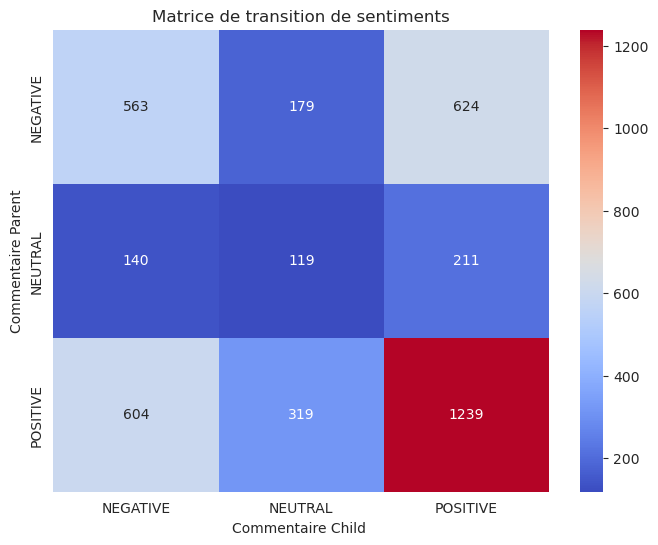

/tmp/ipykernel_30769/4233247528.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


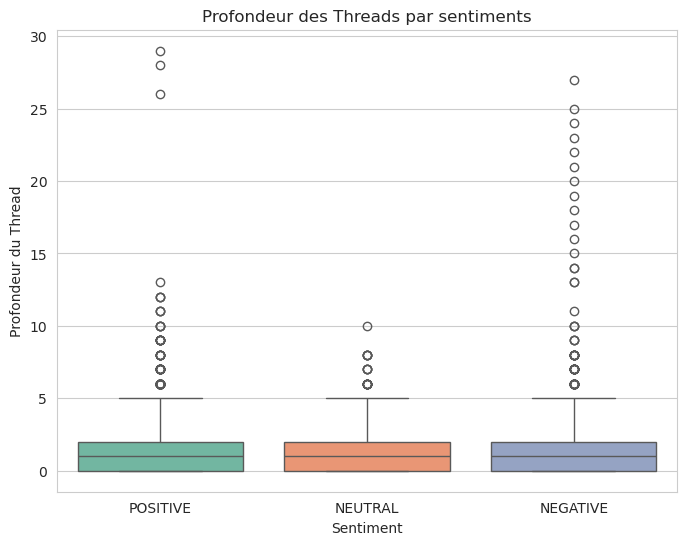

In [17]:
# Sentiment Relationships in Threaded Discussions
import networkx as nx

G = nx.DiGraph()


# J'ajoute tous les coms comme noeuds
for _, row in df.iterrows():

    G.add_node(
        row["comment_id"],
        sentiment=row["sentiment_vader"],
        post_id=row["post_id"]
    )

# J'ajoute toutes les relations pour connetcter les noeuds. je vais garder que les coms qui ont ont eu des réponses. Donc les paires "parent-child"
for _, row in df.iterrows():

    parent = row["parent_id"]

    if parent.startswith("t1_"):

        parent_comment_id = parent.replace("t1_", "")

        if parent_comment_id in df["comment_id"].values:

            G.add_edge(
                parent_comment_id,
                row["comment_id"]
            )

print("nombre de noeuds:", G.number_of_nodes())
print("nombre de liens:", G.number_of_edges())

############################################################################

# Ici je vais créer la matrice de transition. Donc quel snetiment crée une réponse de quel type de sentiments. 
transitions = []

for source, target in G.edges():

    parent_sentiment = G.nodes[source]["sentiment"]
    child_sentiment = G.nodes[target]["sentiment"]

    transitions.append(
        (parent_sentiment, child_sentiment)
    )

transition_counts = Counter(transitions)

transition_df = pd.DataFrame(
    transition_counts.items(),
    columns=["transition", "count"]
)

transition_df[["parent", "child"]] = pd.DataFrame(
    transition_df["transition"].tolist(),
    index=transition_df.index
)

pivot_transitions = transition_df.pivot(
    index="parent",
    columns="child",
    values="count"
).fillna(0)

pivot_transitions

plt.figure(figsize=(8,6))


###################################################################### 3


sns.heatmap(
    pivot_transitions,
    annot=True,
    fmt=".0f",
    cmap="coolwarm"
)

plt.title("Matrice de transition de sentiments")
plt.xlabel("Commentaire Child ")
plt.ylabel("Commentaire Parent")

plt.show()

###########################################################################################

depths = {}

roots = [
    node for node in G.nodes()
    if G.in_degree(node) == 0
]

for root in roots:

    lengths = nx.single_source_shortest_path_length(G, root)

    for node, depth in lengths.items():

        depths[node] = depth

# Attach depth to dataframe
df["depth"] = df["comment_id"].map(depths)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="sentiment_vader",
    y="depth",
    palette="Set2"
)

plt.title("Profondeur des Threads par sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Profondeur du Thread")

plt.show()

> J'ai choisi de représenter mon graphe avec les noeuds comme commentaires et les arretes comme les liaisons entre coms Child et coms Parent.  
> C'est ce qui me semblais le plus intuitif et simple.  
> Donc un si un coms a une réponse on peut pas le savoir il faudra rgarder tout les autres coms pour savoir s'il se trouve dans "parent_id". Mais une fois que tout les coms sont traité ceux qui se retrouvent sans arretes ne sont pas vraiment pértinant car on se concentre sur les réponses de commentaires. A la limite savoir quel type de coms est le plus souvent laissé sans réponse est le plus représenté pourrais etre intéréssant.

> On voit sur la heatmap que la pair de commentaires "parent-child" la plus fréquente, c'est régaire positivement a un commentaire positif, assez largement (~1200).  
> Ensuite viennent les paires "Neg-Pos", "Pos-Neg" et "Neg-Neg" qui ont plus ou moins la même fréquence, (~600).  
> Et enfin viennent les combinaisons de pairs qui contiennent un comemntaire neutre, avec la paire la moins fréquente étant "neutre-neutre".  
> La paire "Pos-Pos" est la plus fréquente probablement car les gens préférent intérgair avec des gens avec qui ils partagent le même avis et qui sont positifs.  
> Ensuite il y a les pairs de sentiments différents et de "neg-neg" qui représentent bien le fil d'un discussion de personne de vue contraire. Donc c'est tout les débats etc.  
> Et les pairs avec des commentaires neutre sont les moins fréquent car probalement ils sont moins polémique donc incitent pas tant à réagire.
  
> On voit que les threads de commentaires négatifs sont fréquement plus longs. Donc provoquer les gens génére plus de réaction surtout si c'est des provocations négative. (BadBuzz).    
  
> Les threads de commentaires négatifs sont généralement plus long mais les threads les plus long sont positifs donc il faudrait vérifier ces threads pour en identifier la cause précisément. Est ce le sujet ? Un outlier? Les utilisateurs ? Du spam ?  